# 05: XGBoost Model — March Madness Prediction

**Prerequisite:** Run `04a_feature_building.ipynb` then `04b_matchup_building.ipynb`

### Approach
```
Training:   2004-2024 matchups (regular season cross-season + tournament)
Validation: 2025 matchups (test model accuracy)
Prediction: 2026 tournament (generate Kaggle submission)
```

### Evaluation Metric: Brier Score
- Brier Score = mean((predicted - actual)^2)
- 0.0 = perfect, 0.25 = coin flip (all 0.5 predictions)
- < 0.20 = decent, < 0.18 = good, < 0.15 = competitive

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import log_loss, accuracy_score, brier_score_loss
from sklearn.calibration import calibration_curve

from src.data_loader import load_sample_submission, load_teams, PROCESSED_DIR
from src.utils import validate_submission, parse_submission_id

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)

teams = load_teams('M')
team_lookup = dict(zip(teams['TeamID'], teams['TeamName']))

print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


In [2]:
# Load matchup features (built in 04b)
matchups = pd.read_csv(PROCESSED_DIR / 'matchup_features.csv')
print(f"All matchups: {len(matchups):,} rows")
print(f"Seasons: {matchups['Season'].min()} to {matchups['Season'].max()}")
print(f"GameType: {matchups['GameType'].value_counts().to_dict()}")

# Load team features (for generating 2026 predictions)
team_features = pd.read_csv(PROCESSED_DIR / 'team_features.csv')
print(f"\nTeam features: {len(team_features):,} rows")

# Load sample submission
sample_sub = load_sample_submission(stage=2)
print(f"\nSample submission (2026): {len(sample_sub):,} rows")
sample_sub.head()

All matchups: 118,311 rows
Seasons: 2003 to 2026
GameType: {'Regular': 116862, 'Tournament': 1449}

Team features: 8,346 rows

Sample submission (2026): 132,133 rows


,ID,Pred
0,2026_1101_1102,0.5
1,2026_1101_1103,0.5
2,2026_1101_1104,0.5
3,2026_1101_1105,0.5
4,2026_1101_1106,0.5


---
## 2. Train / Validation Split (Time-Based)

No random split — we split by time to mimic real prediction.

In [3]:
# Feature columns = all _Diff columns, excluding highly correlated ones
# Dropped to reduce multicollinearity & overfitting:
#   SAG_Rank_Diff        -> NaN for 2025, redundant with Composite
#   POM_Rank_Diff        -> 0.98 correlated with Composite_Rank_Diff
#   WinPct_Diff          -> 0.87 with Elo, 0.84 with AvgMargin
#   AvgPointsFor_Diff    -> redundant (AvgMargin = For - Against)
#   AvgPointsAgainst_Diff-> redundant (AvgMargin = For - Against)
#   Last15WinPct_Diff    -> 0.82 with Last15AvgMargin_Diff

drop_cols = ['SAG_Rank_Diff', 'POM_Rank_Diff', 'WinPct_Diff',
             'AvgPointsFor_Diff', 'AvgPointsAgainst_Diff', 'Last15WinPct_Diff']

feature_cols = [c for c in matchups.columns if c.endswith('_Diff') and c not in drop_cols]
print(f"Feature columns ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  {col}")
print(f"\nDropped ({len(drop_cols)}): {drop_cols}")

Feature columns (12):
  AvgMargin_Diff
  eFG_Off_Diff
  TORate_Off_Diff
  ORBRate_Off_Diff
  FTRate_Off_Diff
  Elo_RegSeason_Diff
  Composite_Rank_Diff
  SeedNum_Diff
  IsSeeded_Diff
  ConfStrength_Rank_Diff
  Last15AvgMargin_Diff
  ConfTourneyChamp_Diff

Dropped (6): ['SAG_Rank_Diff', 'POM_Rank_Diff', 'WinPct_Diff', 'AvgPointsFor_Diff', 'AvgPointsAgainst_Diff', 'Last15WinPct_Diff']


In [4]:
# Time-based split
matchups = matchups.drop(columns=drop_cols, errors='ignore')

train_data = matchups[matchups['Season'] <= 2024].copy()
val_data = matchups[matchups['Season'] == 2025].copy()

# Drop rows with NaN in features
train_clean = train_data.dropna(subset=feature_cols)
val_clean = val_data.dropna(subset=feature_cols)

X_train = train_clean[feature_cols]
y_train = train_clean['Target']

X_val = val_clean[feature_cols]
y_val = val_clean['Target']

print(f"Training:   {X_train.shape[0]:,} rows ({train_data['Season'].min()}-{train_data['Season'].max()})")
print(f"Validation: {X_val.shape[0]:,} rows (2025)")
print(f"Features:   {X_train.shape[1]}")
print(f"\nDropped (NaN): {len(train_data) - len(train_clean):,} train, {len(val_data) - len(val_clean):,} val")
print(f"\nTarget balance:")
print(f"  Train: {y_train.value_counts().to_dict()}")
print(f"  Val:   {y_val.value_counts().to_dict()}")

Training:   108,758 rows (2003-2024)
Validation: 5,650 rows (2025)
Features:   12

Dropped (NaN): 29 train, 0 val

Target balance:
  Train: {0: 55902, 1: 52856}
  Val:   {1: 2867, 0: 2783}


---
## 3. Train XGBoost Model

In [38]:
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=2000,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    early_stopping_rounds=200,
    random_state=42,
    verbosity=0,
    reg_alpha=0.1,
    reg_lambda=1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best validation log loss: {model.best_score:.4f}")

[0]	validation_0-logloss:0.67540	validation_1-logloss:0.67834
[100]	validation_0-logloss:0.54646	validation_1-logloss:0.61064
[200]	validation_0-logloss:0.51406	validation_1-logloss:0.61560
[234]	validation_0-logloss:0.50363	validation_1-logloss:0.61675

Best iteration: 34
Best validation log loss: 0.6074


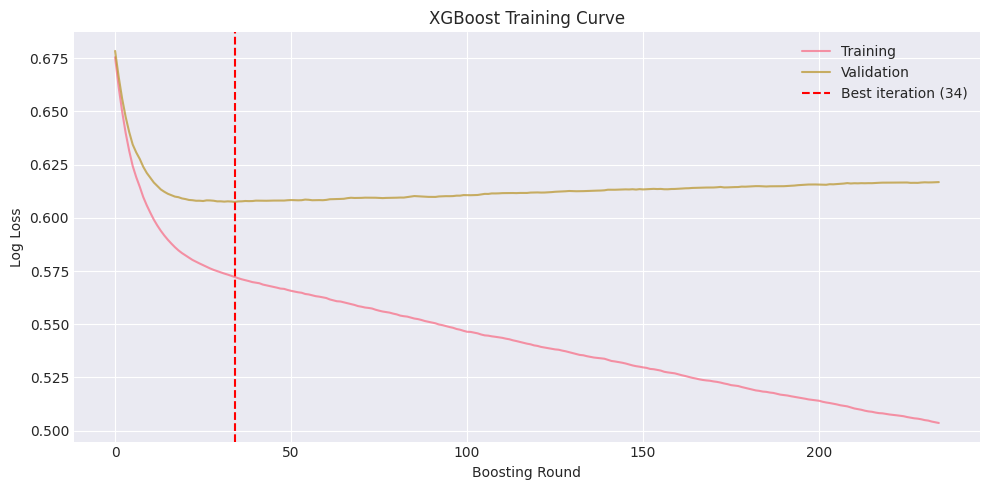

Gap between training and validation = overfitting.
Early stopping prevents excessive overfitting.


In [39]:
# Training curves
results = model.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['validation_0']['logloss'], label='Training', alpha=0.75)
ax.plot(results['validation_1']['logloss'], label='Validation', alpha=0.75)
ax.axvline(model.best_iteration, color='red', linestyle='--', label=f'Best iteration ({model.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

print("Gap between training and validation = overfitting.")
print("Early stopping prevents excessive overfitting.")

---
## 4. Feature Importance

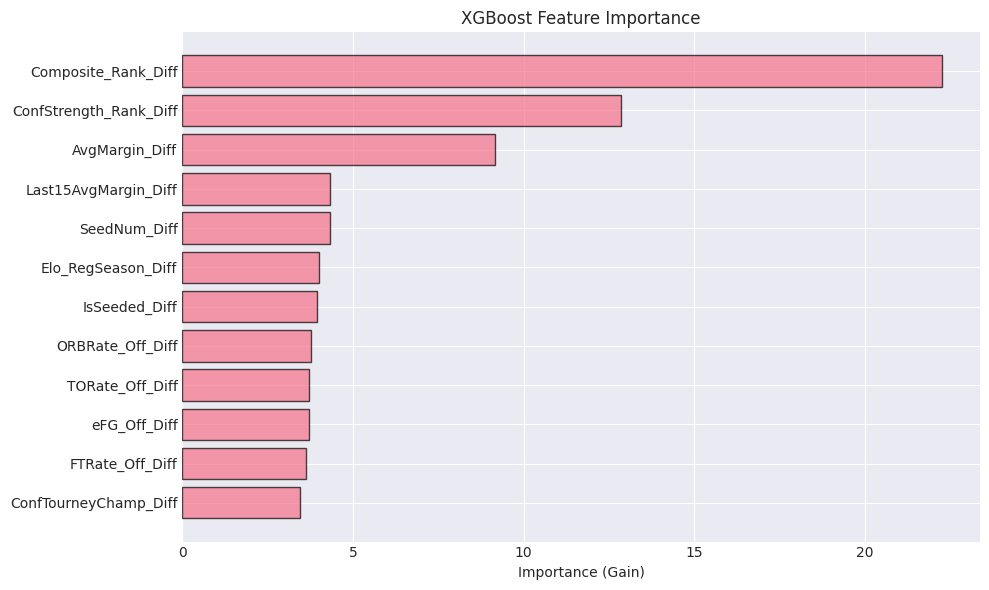


Top features:
  Composite_Rank_Diff: 22.26
  ConfStrength_Rank_Diff: 12.84
  AvgMargin_Diff: 9.16
  Last15AvgMargin_Diff: 4.33
  SeedNum_Diff: 4.33


In [40]:
# Feature importance (gain-based)
importance = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': importance.keys(),
    'Importance': importance.values()
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['Feature'], importance_df['Importance'], edgecolor='black', alpha=0.7)
ax.set_xlabel('Importance (Gain)')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

print("\nTop features:")
for _, row in importance_df.sort_values('Importance', ascending=False).head(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.2f}")

---
## 5. Evaluate on 2025 Tournament

The real test: how well does the model predict actual tournament games?

In [41]:
# Filter validation to tournament games only
val_tourney = val_clean[val_clean['GameType'] == 'Tournament'].copy()

if len(val_tourney) > 0:
    X_val_t = val_tourney[feature_cols]
    y_val_t = val_tourney['Target']
    
    # Predict probabilities
    val_tourney['Pred'] = model.predict_proba(X_val_t)[:, 1]
    val_tourney['PredClass'] = (val_tourney['Pred'] > 0.5).astype(int)
    
    # Metrics
    brier = brier_score_loss(y_val_t, val_tourney['Pred'])
    ll = log_loss(y_val_t, val_tourney['Pred'])
    acc = accuracy_score(y_val_t, val_tourney['PredClass'])
    
    print(f"2025 Tournament Results:")
    print(f"  Games:       {len(val_tourney)}")
    print(f"  Brier Score: {brier:.4f}  (0=perfect, 0.25=coin flip)")
    print(f"  Log Loss:    {ll:.4f}")
    print(f"  Accuracy:    {acc:.1%}")
else:
    print("No 2025 tournament games in validation set.")
    print("Evaluating on all 2025 validation data instead.")
    
    val_clean_copy = val_clean.copy()
    val_clean_copy['Pred'] = model.predict_proba(X_val)[:, 1]
    val_clean_copy['PredClass'] = (val_clean_copy['Pred'] > 0.5).astype(int)
    
    brier = brier_score_loss(y_val, val_clean_copy['Pred'])
    ll = log_loss(y_val, val_clean_copy['Pred'])
    acc = accuracy_score(y_val, val_clean_copy['PredClass'])
    print(f"2025 All Games:")
    print(f"  Games:       {len(val_clean)}")
    print(f"  Brier Score: {brier:.4f}  (0=perfect, 0.25=coin flip)")
    print(f"  Log Loss:    {ll:.4f}")
    print(f"  Accuracy:    {acc:.1%}")

2025 Tournament Results:
  Games:       67
  Brier Score: 0.1731  (0=perfect, 0.25=coin flip)
  Log Loss:    0.5144
  Accuracy:    73.1%


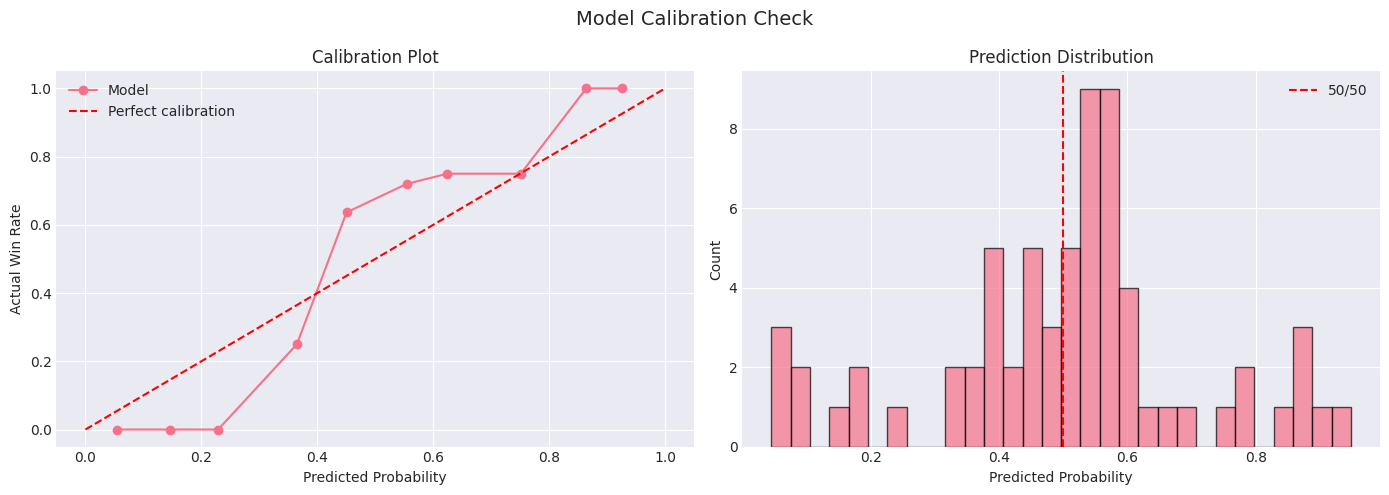

Calibration: points close to red line = well calibrated.
Distribution: should NOT be all clustered at 0.5 (would mean model isn't confident).


In [9]:
# Calibration plot: are predicted probabilities accurate?
eval_data = val_tourney if len(val_tourney) > 0 else val_clean.copy()
if 'Pred' not in eval_data.columns:
    eval_data = eval_data.copy()
    eval_data['Pred'] = model.predict_proba(eval_data[feature_cols])[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
prob_true, prob_pred = calibration_curve(eval_data['Target'], eval_data['Pred'], n_bins=10)
axes[0].plot(prob_pred, prob_true, 'o-', label='Model')
axes[0].plot([0, 1], [0, 1], 'r--', label='Perfect calibration')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Actual Win Rate')
axes[0].set_title('Calibration Plot')
axes[0].legend()

# Prediction distribution
axes[1].hist(eval_data['Pred'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0.5, color='red', linestyle='--', label='50/50')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Distribution')
axes[1].legend()

plt.suptitle('Model Calibration Check', fontsize=14)
plt.tight_layout()
plt.show()

print("Calibration: points close to red line = well calibrated.")
print("Distribution: should NOT be all clustered at 0.5 (would mean model isn't confident).")

In [10]:
# Show some example predictions with team names
if len(val_tourney) > 0:
    examples = val_tourney.copy()
    examples['Team1Name'] = examples['Team1'].map(team_lookup)
    examples['Team2Name'] = examples['Team2'].map(team_lookup)
    examples['Actual'] = examples['Target'].map({1: 'Team1 Won', 0: 'Team2 Won'})
    examples['Confident'] = (examples['Pred'] - 0.5).abs()
    
    print("MOST CONFIDENT CORRECT PREDICTIONS:")
    correct = examples[examples['Target'] == examples['PredClass']].sort_values('Confident', ascending=False)
    display(correct[['Team1Name', 'Team2Name', 'Pred', 'Actual']].head(10))
    
    print("\nBIGGEST UPSETS (model got wrong):")
    wrong = examples[examples['Target'] != examples['PredClass']].sort_values('Confident', ascending=False)
    display(wrong[['Team1Name', 'Team2Name', 'Pred', 'Actual']].head(10))

MOST CONFIDENT CORRECT PREDICTIONS:


,Team1Name,Team2Name,Pred,Actual
118249,Alabama St,Auburn,0.045418,Team2 Won
118254,SIUE,Houston,0.050708,Team2 Won
118269,Duke,Mt St Mary's,0.948384,Team1 Won
118263,Montana,Wisconsin,0.069413,Team2 Won
118270,Florida,Norfolk St,0.902667,Team1 Won
118275,Bryant,Michigan St,0.100322,Team2 Won
118258,NE Omaha,St John's,0.102121,Team2 Won
118264,Alabama,Robert Morris,0.881707,Team1 Won
118259,Tennessee,Wofford,0.868133,Team1 Won
118272,Iowa St,Lipscomb,0.868078,Team1 Won



BIGGEST UPSETS (model got wrong):


,Team1Name,Team2Name,Pred,Actual
118255,Clemson,McNeese St,0.704815,Team2 Won
118252,Drake,Missouri,0.381267,Team1 Won
118295,Iowa St,Mississippi,0.604736,Team2 Won
118280,Arkansas,St John's,0.397256,Team1 Won
118279,St Mary's CA,Vanderbilt,0.410389,Team1 Won
118247,Texas,Xavier,0.586087,Team2 Won
118304,Alabama,Duke,0.575254,Team2 Won
118309,Duke,Houston,0.554890,Team2 Won
118253,Georgia,Gonzaga,0.545639,Team2 Won
118251,Creighton,Louisville,0.462092,Team1 Won


---
## 6. Generate 2026 Submission

For every possible matchup in the submission file, predict the probability that Team1 (lower ID) wins.

In [11]:
# Parse submission IDs to get matchups
sub_matchups = []
for sub_id in sample_sub['ID']:
    season, team1, team2 = parse_submission_id(sub_id)
    sub_matchups.append({'ID': sub_id, 'Season': season, 'Team1': team1, 'Team2': team2})

sub_df = pd.DataFrame(sub_matchups)
print(f"Submission matchups: {len(sub_df):,}")
print(f"Seasons in submission: {sub_df['Season'].unique()}")
sub_df.head()

Submission matchups: 132,133
Seasons in submission: [2026]


,ID,Season,Team1,Team2
0,2026_1101_1102,2026,1101,1102
1,2026_1101_1103,2026,1101,1103
2,2026_1101_1104,2026,1101,1104
3,2026_1101_1105,2026,1101,1105
4,2026_1101_1106,2026,1101,1106


In [12]:
# Build features for 2026 matchups
# Cross-season: use 2025 stats to predict 2026
features_2025 = team_features[team_features['Season'] == 2025].copy()
print(f"Teams with 2025 stats: {len(features_2025)}")

# Team-level feature names (without _Diff suffix) — must match feature_cols
diff_features = ['AvgMargin',
                 'eFG_Off', 'TORate_Off', 'ORBRate_Off', 'FTRate_Off',
                 'Elo_RegSeason', 'Composite_Rank',
                 'SeedNum', 'IsSeeded',
                 'ConfStrength_Rank', 'Last15AvgMargin', 'ConfTourneyChamp']

print(f"Diff features: {len(diff_features)} (should match {len(feature_cols)} feature_cols)")

# Build differentials for each submission matchup
sub_features = []
missing_teams = set()

for _, row in sub_df.iterrows():
    t1 = features_2025[features_2025['TeamID'] == row['Team1']]
    t2 = features_2025[features_2025['TeamID'] == row['Team2']]
    
    feat_row = {'ID': row['ID']}
    
    if len(t1) == 0 or len(t2) == 0:
        if len(t1) == 0:
            missing_teams.add(row['Team1'])
        if len(t2) == 0:
            missing_teams.add(row['Team2'])
        # Use 0.0 (no info) for missing teams
        for col in feature_cols:
            feat_row[col] = 0.0
        sub_features.append(feat_row)
        continue
    
    t1, t2 = t1.iloc[0], t2.iloc[0]
    
    for col in diff_features:
        val1, val2 = t1.get(col, np.nan), t2.get(col, np.nan)
        feat_row[f'{col}_Diff'] = val1 - val2 if pd.notna(val1) and pd.notna(val2) else 0.0
    
    sub_features.append(feat_row)

sub_feat_df = pd.DataFrame(sub_features)
print(f"\nSubmission features built: {len(sub_feat_df):,}")
if missing_teams:
    print(f"Teams without 2025 data: {len(missing_teams)} (will predict 0.5)")

Teams with 2025 stats: 364
Diff features: 12 (should match 12 feature_cols)

Submission features built: 132,133
Teams without 2025 data: 364 (will predict 0.5)


In [13]:
# Predict
X_sub = sub_feat_df[feature_cols]

# Fill any remaining NaN with 0
X_sub = X_sub.fillna(0.0)

predictions = model.predict_proba(X_sub)[:, 1]

# Clip predictions to avoid extreme log loss penalties
predictions = np.clip(predictions, 0.01, 0.99)

# Build submission
submission = pd.DataFrame({
    'ID': sub_feat_df['ID'],
    'Pred': predictions
})

print(f"Submission shape: {submission.shape}")
print(f"Prediction stats:")
print(f"  Mean: {submission['Pred'].mean():.3f}")
print(f"  Std:  {submission['Pred'].std():.3f}")
print(f"  Min:  {submission['Pred'].min():.3f}")
print(f"  Max:  {submission['Pred'].max():.3f}")
submission.head(10)

Submission shape: (132133, 2)
Prediction stats:
  Mean: 0.484
  Std:  0.195
  Min:  0.026
  Max:  0.973


,ID,Pred
0,2026_1101_1102,0.490935
1,2026_1101_1103,0.270755
2,2026_1101_1104,0.059862
3,2026_1101_1105,0.732845
4,2026_1101_1106,0.665646
5,2026_1101_1107,0.574929
6,2026_1101_1108,0.735172
7,2026_1101_1110,0.512622
8,2026_1101_1111,0.463148
9,2026_1101_1112,0.048554


---
## 7. Sanity Check & Save Submission

In [14]:
# Validate submission format
validation_result = validate_submission(submission, sample_sub)
print(f"Valid: {validation_result['valid']}")
if validation_result['errors']:
    print(f"Errors: {validation_result['errors']}")
if validation_result['warnings']:
    print(f"Warnings: {validation_result['warnings']}")

Valid: True


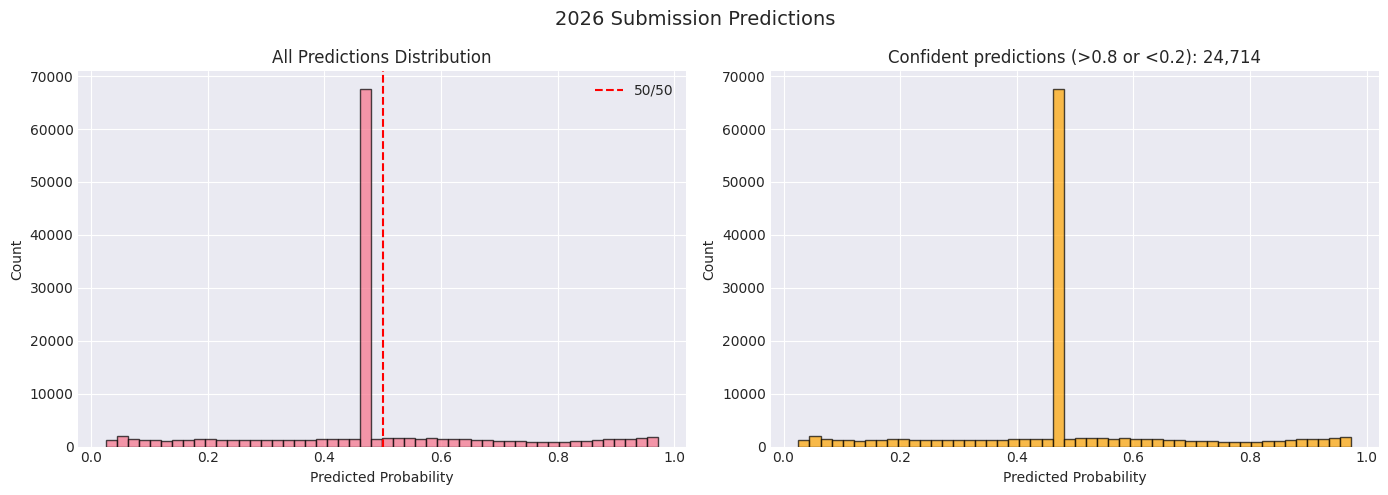

In [15]:
# Distribution of predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(submission['Pred'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0.5, color='red', linestyle='--', label='50/50')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('All Predictions Distribution')
axes[0].legend()

# Zoom into confident predictions
confident = submission[(submission['Pred'] < 0.2) | (submission['Pred'] > 0.8)]
axes[1].hist(submission['Pred'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Confident predictions (>0.8 or <0.2): {len(confident):,}')

plt.suptitle('2026 Submission Predictions', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Most lopsided predicted matchups (top favorites)
sub_with_names = submission.copy()
parsed = sub_with_names['ID'].str.split('_', expand=True)
sub_with_names['Team1'] = parsed[1].astype(int)
sub_with_names['Team2'] = parsed[2].astype(int)
sub_with_names['Team1Name'] = sub_with_names['Team1'].map(team_lookup)
sub_with_names['Team2Name'] = sub_with_names['Team2'].map(team_lookup)

# Filter to only 2026 season
sub_2026 = sub_with_names[sub_with_names['ID'].str.startswith('2026')]

print("TOP 15: Team1 heavily favored (highest Pred):")
display(sub_2026.sort_values('Pred', ascending=False)[['Team1Name', 'Team2Name', 'Pred']].head(15))

print("\nTOP 15: Team2 heavily favored (lowest Pred):")
display(sub_2026.sort_values('Pred', ascending=True)[['Team1Name', 'Team2Name', 'Pred']].head(15))

TOP 15: Team1 heavily favored (highest Pred):


,Team1Name,Team2Name,Pred
39698,Kansas,New Orleans,0.972723
32692,Gonzaga,TX Southern,0.972581
5188,Arkansas,New Orleans,0.972547
6273,Auburn,Rider,0.972457
31774,Georgia,MD E Shore,0.972446
66254,Xavier,East Texas A&M,0.972285
19867,Creighton,MD E Shore,0.972246
39805,Kansas,ULM,0.972225
40615,Kentucky,NJIT,0.972185
3944,Arizona,East Texas A&M,0.972098



TOP 15: Team2 heavily favored (lowest Pred):


,Team1Name,Team2Name,Pred
1455,Alabama A&M,Arizona,0.025522
19314,Coppin St,Oregon,0.025741
19327,Coppin St,Purdue,0.026684
19231,Coppin St,Kentucky,0.026744
32813,Grambling,Maryland,0.026770
28823,Florida A&M,Maryland,0.026795
22518,Delaware St,Houston,0.027035
46051,MD E Shore,Texas A&M,0.027086
51297,NC Central,Tennessee,0.027102
1732,Alabama A&M,Texas A&M,0.027210


In [17]:
# Save submission
import os
sub_dir = PROCESSED_DIR.parent / 'submissions'
os.makedirs(sub_dir, exist_ok=True)

output_path = sub_dir / 'submission_xgb_v1.csv'
submission.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Shape: {submission.shape}")
print(f"\nReady to upload to Kaggle!")

Saved: /home/sagemaker-user/NCAA/NCAA_March_Maddness-2026/submissions/submission_xgb_v1.csv
Shape: (132133, 2)

Ready to upload to Kaggle!


---
## Summary

### Model Configuration
| Parameter | Value |
|-----------|-------|
| Algorithm | XGBoost |
| Objective | binary:logistic |
| Eval Metric | Log Loss |
| Max Depth | 6 |
| Learning Rate | 0.05 |
| Early Stopping | 50 rounds |

### Results
- **Training log loss:** (check output above)
- **Validation log loss:** (check output above)
- **2025 tournament accuracy:** (check output above)

### Next Steps
- Tune hyperparameters (try different max_depth, learning_rate)
- Add more features (coach data, conference strength, momentum)
- Try ensemble with LightGBM
- Stage 2: retrain with 2026 regular season data when available